# Análisis de Datos

## Introducción

Este notebook presenta un descriptivo de los resultados obtenidos durante la extracción de vulnerabilidades:

- **CodeQL**: Análisis estático de código (SAST) - identifica vulnerabilidades en el código fuente
- **Grype**: Análisis de componentes de software (SCA) - identifica vulnerabilidades en dependencias

# Análisis CodeQL: Vulnerabilidades en Código Fuente

## ¿De dónde vienen los datos?

CodeQL ejecuta análisis estático sobre el código fuente y genera resultados en formato **SARIF v2.1.0** (formato estándar de la industria para reportes de análisis de seguridad).

### Mapeo de datos: SARIF -> JSON normalizado

| Dato original (SARIF) | Dato normalizado | Significado |
|---|---|---|
| `level` | `level` | Severidad del problema: `"error"` (crítico), `"warning"` (medio), `"note"` (bajo) |
| `ruleId` | `rule_id` | Identificador de la regla de seguridad violada (ej: `py/sql-injection`) |
| `message.text` | `message` | Descripción legible del problema |
| `location.physicalLocation` | `file` + `region` | Ubicación exacta: archivo y línea/columna afectada |
| `kind`, `properties` | Se preservan | Información adicional para debugging |

### Decisión de diseño

**Se mantiene el `level` exactamente como lo proporciona SARIF**, sin transformación adicional. A diferencia de Grype (que mapea números a categorías), CodeQL ya viene categorizado.

### Visualizaciones esperadas

- Distribución de problemas por severidad (error/warning/note)
- Reglas más comunes encontradas

In [109]:
import sys
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Setup de rutas
project_root = Path().cwd().parent.parent
data_results = project_root / "data" / "results"

print(f"📁 Directorio de resultados: {data_results}")
print(f"✓ Proyecto raíz: {project_root}")

📁 Directorio de resultados: /workspaces/SBOMs-Tarea4/data/results
✓ Proyecto raíz: /workspaces/SBOMs-Tarea4


In [110]:
# Cargar todos los análisis CodeQL
codeql_files = sorted(data_results.glob("*-codeql.json"))

print(f"\n📂 Buscando archivos CodeQL en: {data_results}")
print(f"✓ Archivos encontrados: {len(codeql_files)}\n")

# Consolidar en un solo DataFrame
data_consolidado = []

for archivo in codeql_files:
    with open(archivo, 'r', encoding='utf-8') as f:
        contenido = json.load(f)

    repo_name = archivo.stem.replace('-codeql', '')
    issues = contenido.get('issues', [])

    for issue in issues:
        issue['repo'] = repo_name
        data_consolidado.append(issue)

df_codeql = pd.DataFrame(data_consolidado)

print(f"📊 Total de problemas cargados: {len(df_codeql)}")
print(
    f"📋 Repositorios únicos: {df_codeql['repo'].nunique() if len(df_codeql) > 0 else 0}\n")


📂 Buscando archivos CodeQL en: /workspaces/SBOMs-Tarea4/data/results
✓ Archivos encontrados: 5

📊 Total de problemas cargados: 790
📋 Repositorios únicos: 4



In [111]:
# Estadísticas por severidad
if len(df_codeql) > 0:
    stats_severity = df_codeql['level'].value_counts(
    ).sort_index(ascending=False)

    print("📊 Problemas por Nivel de Severidad:")
    print("=" * 50)
    for nivel, cantidad in stats_severity.items():
        emoji = "🔴" if nivel == "error" else "🟡" if nivel == "warning" else "⚪"
        porcentaje = (cantidad / len(df_codeql)) * 100
        print(f"{emoji} {nivel.upper()}: {cantidad} ({porcentaje:.1f}%)")

    print(f"\n📈 Total general: {len(df_codeql)} problemas encontrados")
else:
    print("❌ No hay datos de CodeQL disponibles")

📊 Problemas por Nivel de Severidad:
🟡 WARNING: 790 (100.0%)

📈 Total general: 790 problemas encontrados


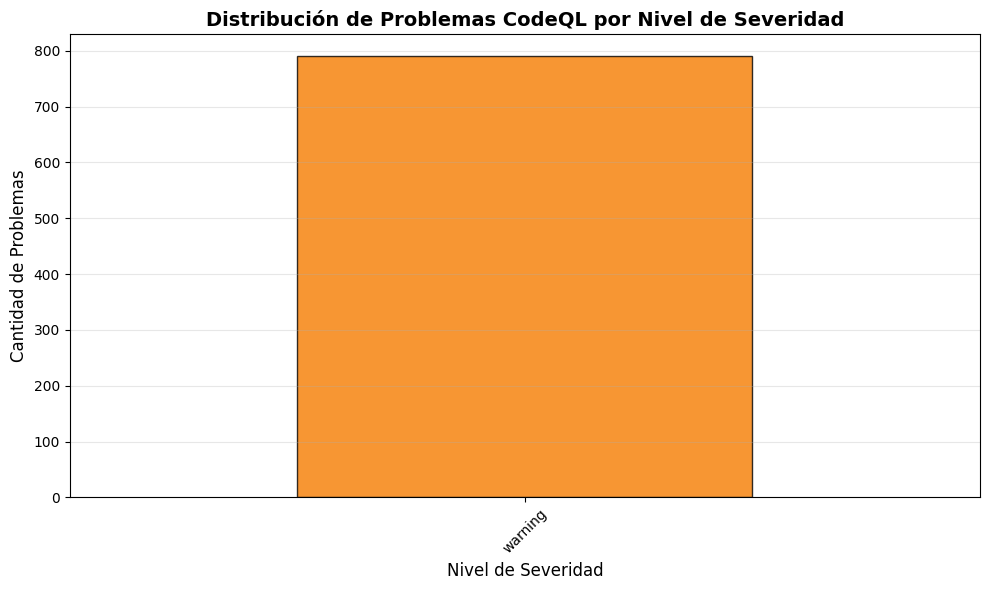

In [112]:
# Gráfico: Distribución por severidad
if len(df_codeql) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))

    stats_severity = df_codeql['level'].value_counts(
    ).sort_index(ascending=False)

    # Colores según severidad
    colores = {'error': '#d32f2f', 'warning': '#f57c00', 'note': '#7cb342'}
    color_list = [colores.get(nivel, '#757575')
                  for nivel in stats_severity.index]

    stats_severity.plot(kind='bar', ax=ax, color=color_list,
                        edgecolor='black', alpha=0.8)

    ax.set_title('Distribución de Problemas CodeQL por Nivel de Severidad',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Nivel de Severidad', fontsize=12)
    ax.set_ylabel('Cantidad de Problemas', fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("❌ No hay datos disponibles para graficar")

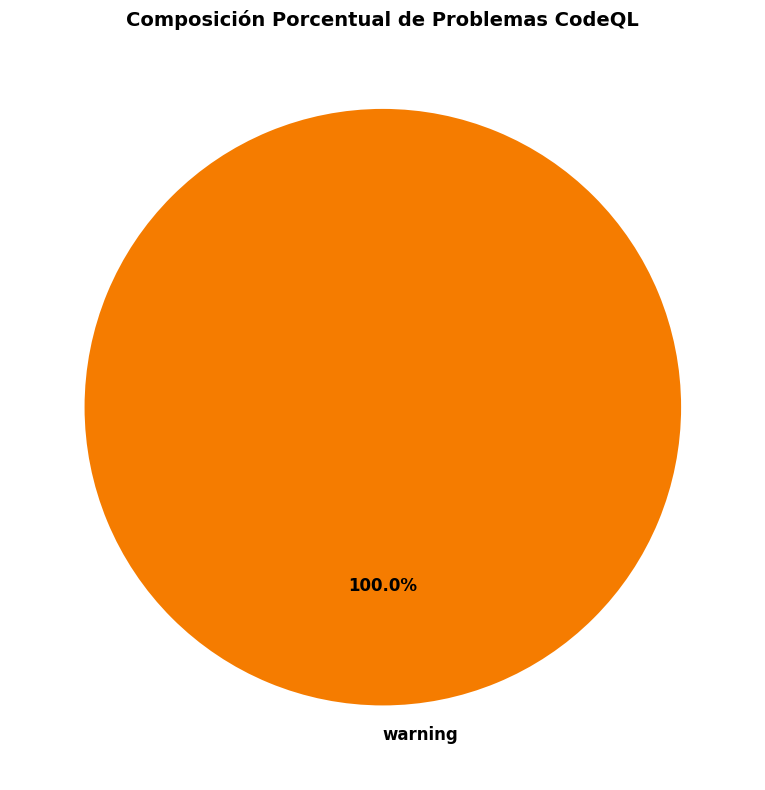

In [113]:
# Gráfico: Composición por severidad
if len(df_codeql) > 0:
    fig, ax = plt.subplots(figsize=(10, 8))

    stats_severity = df_codeql['level'].value_counts()

    colores = {'error': '#d32f2f', 'warning': '#f57c00', 'note': '#7cb342'}
    color_list = [colores.get(nivel, '#757575')
                  for nivel in stats_severity.index]

    wedges, texts, autotexts = ax.pie(
        stats_severity.values,
        labels=stats_severity.index,
        autopct='%1.1f%%',
        colors=color_list,
        startangle=90,
        textprops={'fontsize': 12, 'weight': 'bold'}
    )

    ax.set_title('Composición Porcentual de Problemas CodeQL',
                 fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print("❌ No hay datos disponibles para graficar")

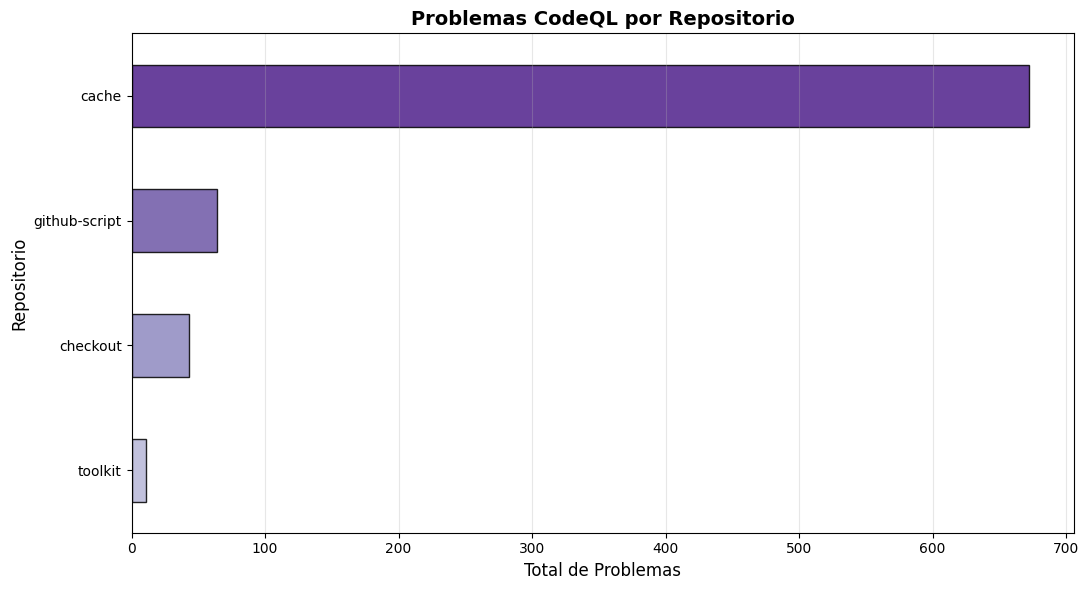


 Desviación estándar de problemas por repositorio: 274.60
 Promedio de problemas por repositorio: 197.50


In [114]:
# Gráfico: Problemas por repositorio (CodeQL)
if len(df_codeql) > 0:
    fig, ax = plt.subplots(figsize=(11, 6))

    issues_por_repo = df_codeql['repo'].value_counts(
    ).sort_values(ascending=True)

    # Colores del gradiente (más oscuro = más issues)
    colores_gradiente = plt.cm.Purples(
        np.linspace(0.4, 0.9, len(issues_por_repo)))

    issues_por_repo.plot(
        kind='barh', ax=ax, color=colores_gradiente, edgecolor='black', alpha=0.85)

    ax.set_title('Problemas CodeQL por Repositorio',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Total de Problemas', fontsize=12)
    ax.set_ylabel('Repositorio', fontsize=12)
    ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("❌ No hay datos disponibles para graficar")

desv_p = 0
for cantidad_issues in issues_por_repo:
    desv_p += (cantidad_issues - issues_por_repo.mean()) ** 2
desv_p = (desv_p / len(issues_por_repo)) ** 0.5
print(f"\n Desviación estándar de problemas por repositorio: {desv_p:.2f}")
print(f" Promedio de problemas por repositorio: {issues_por_repo.mean():.2f}")

In [115]:
# Top 10 reglas más comunes
if len(df_codeql) > 0:
    top_rules = df_codeql['rule_id'].value_counts().head(10)

    print("\n🎯 Top 10 Reglas de Seguridad Más Frecuentes:")
    print("=" * 70)
    for idx, (rule, count) in enumerate(top_rules.items(), 1):
        porcentaje = (count / len(df_codeql)) * 100
        print(f"{idx:2d}. {rule:40s} {count:3d} ({porcentaje:5.1f}%)")
else:
    print("❌ No hay datos disponibles")


🎯 Top 10 Reglas de Seguridad Más Frecuentes:
 1. js/useless-expression                    256 ( 32.4%)
 2. js/useless-assignment-to-local           181 ( 22.9%)
 3. js/trivial-conditional                   105 ( 13.3%)
 4. js/unneeded-defensive-code                90 ( 11.4%)
 5. js/unused-local-variable                  32 (  4.1%)
 6. js/whitespace-contradicts-precedence      24 (  3.0%)
 7. js/automatic-semicolon-insertion          24 (  3.0%)
 8. js/superfluous-trailing-arguments         22 (  2.8%)
 9. js/comparison-between-incompatible-types  17 (  2.2%)
10. js/redundant-assignment                    8 (  1.0%)


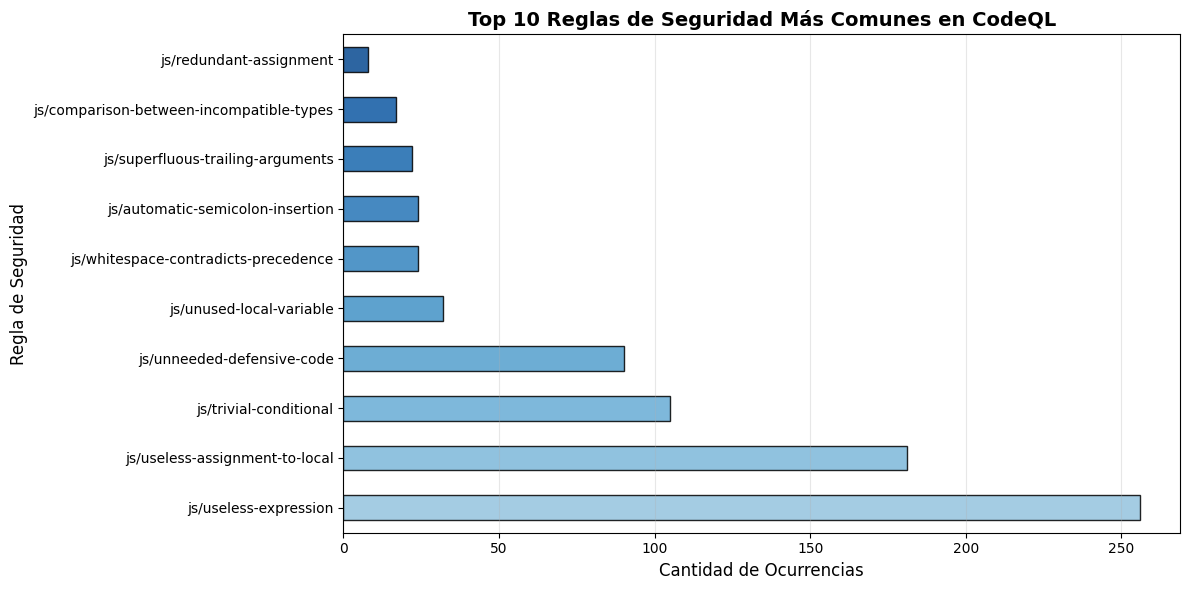

In [116]:
# Gráfico: Top 10 reglas más comunes
if len(df_codeql) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))

    top_rules = df_codeql['rule_id'].value_counts().head(10)

    # Colores del gradiente (más oscuro = más frecuente)
    colores_gradiente = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_rules)))

    top_rules.plot(kind='barh', ax=ax, color=colores_gradiente,
                   edgecolor='black', alpha=0.85)

    ax.set_title('Top 10 Reglas de Seguridad Más Comunes en CodeQL',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Cantidad de Ocurrencias', fontsize=12)
    ax.set_ylabel('Regla de Seguridad', fontsize=12)
    ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("❌ No hay datos disponibles para graficar")

# Análisis Grype: Vulnerabilidades en Dependencias

## ¿De dónde vienen los datos?

Grype escanea fuentes de dependencias (package.json, requirements.txt, pom.xml, etc.) y las compara contra bases de datos de vulnerabilidades conocidas (CVE, NVD). Devuelve resultados en JSON con información de cada vulnerabilidad encontrada.

### Mapeo de datos: JSON de Grype -> JSON normalizado

| Dato original (Grype) | Dato normalizado | Significado |
|---|---|---|
| `artifact.name` | `package_name` | Nombre de la librería vulnerable (ej: `django`, `lodash`) |
| `artifact.version` | `current_version` | Versión de la librería actualmente instalada |
| `vulnerability.id` | `vuln_id` | Identificador único: CVE-XXXX-XXXXX o equivalente |
| `metadata.cvss[0].score` | `cvss_score` | Puntuación CVSS 0.0-10.0 (escala de severidad numérica) |
| — | `vuln_severity` | **MAPEO**: CVSS→categoría: critical (≥9.0), high (≥7.0), medium (≥4.0), low (<4.0) |
| `fix.versions[0]` | `fix_version` | Versión con el parche disponible (o "N/A" si no hay) |
| `vulnerability.description` | `message` | Descripción del problema |

### Decisión de diseño

**Se realiza transformación CVSS score -> severidad** para mayor legibilidad, pero **se preservan AMBOS valores**. Esto permite:

- Comparar fácilmente con SLAs ("critical en 24h, high en 72h")
- Mantener precisión para usuarios avanzados (CVSS score exacto)

### Visualizaciones esperadas

- Distribución de vulnerabilidades por severidad CVSS
- Paquetes más vulnerables del proyecto

In [117]:
# Cargar todos los análisis Grype
grype_files = sorted(data_results.glob("*-grype.json"))

print(f"\n📂 Buscando archivos Grype en: {data_results}")
print(f"✓ Archivos encontrados: {len(grype_files)}\n")

# Consolidar en un solo DataFrame
data_grype = []

for archivo in grype_files:
    with open(archivo, 'r', encoding='utf-8') as f:
        contenido = json.load(f)

    repo_name = archivo.stem.replace('-grype', '')
    vulns = contenido.get('vulnerabilities', [])

    for vuln in vulns:
        vuln['repo'] = repo_name
        data_grype.append(vuln)

df_grype = pd.DataFrame(data_grype)

print(f"📊 Total de vulnerabilidades cargadas: {len(df_grype)}")
print(
    f"📋 Repositorios únicos: {df_grype['repo'].nunique() if len(df_grype) > 0 else 0}\n")


📂 Buscando archivos Grype en: /workspaces/SBOMs-Tarea4/data/results
✓ Archivos encontrados: 5

📊 Total de vulnerabilidades cargadas: 73
📋 Repositorios únicos: 5



In [118]:
# Estadísticas por severidad (con rangos CVSS)
if len(df_grype) > 0:
    stats_severity = df_grype['vuln_severity'].value_counts()

    # Mapeo de rangos CVSS
    cvss_ranges = {
        'critical': '9.0 - 10.0',
        'high': '7.0 - 8.9',
        'medium': '4.0 - 6.9',
        'low': '0.0 - 3.9'
    }

    print("🔴 Vulnerabilidades por Nivel de Severidad CVSS:")
    print("=" * 60)
    print(f"{'Severidad':<12} {'Cantidad':<10} {'Rango CVSS':<15} {'%':<8}")
    print("=" * 60)

    for severidad in ['critical', 'high', 'medium', 'low']:
        cantidad = stats_severity.get(severidad, 0)
        porcentaje = (cantidad / len(df_grype) *
                      100) if len(df_grype) > 0 else 0
        rango = cvss_ranges.get(severidad, 'N/A')
        emoji = "🔴" if severidad == "critical" else "🟠" if severidad == "high" else "🟡" if severidad == "medium" else "⚪"
        print(f"{emoji} {severidad:<10} {cantidad:<10} {rango:<15} {porcentaje:>6.1f}%")

    print("=" * 60)
    print(f"📈 Total general: {len(df_grype)} vulnerabilidades encontradas")
else:
    print("❌ No hay datos de Grype disponibles")

🔴 Vulnerabilidades por Nivel de Severidad CVSS:
Severidad    Cantidad   Rango CVSS      %       
🔴 critical   0          9.0 - 10.0         0.0%
🟠 high       0          7.0 - 8.9          0.0%
🟡 medium     0          4.0 - 6.9          0.0%
⚪ low        73         0.0 - 3.9        100.0%
📈 Total general: 73 vulnerabilidades encontradas


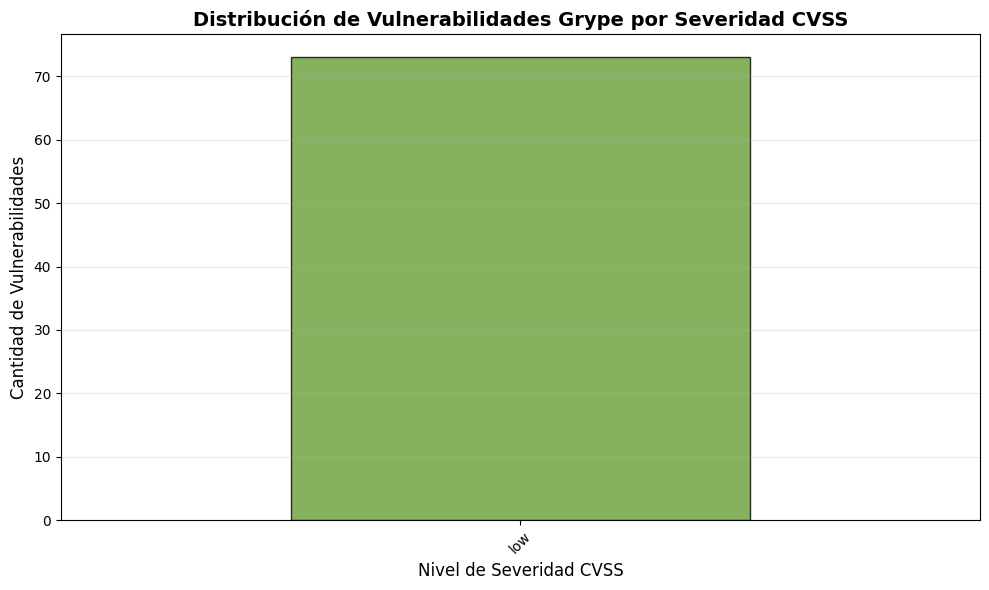

In [119]:
# Gráfico: Distribución por severidad
if len(df_grype) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))

    # Ordenar correctamente: critical > high > medium > low
    severidad_order = ['critical', 'high', 'medium', 'low']
    stats_severity = df_grype['vuln_severity'].value_counts()
    stats_severity = stats_severity.reindex(
        [s for s in severidad_order if s in stats_severity.index])

    # Colores según severidad
    colores = {'critical': '#b71c1c', 'high': '#e64a19',
               'medium': '#fbc02d', 'low': '#689f38'}
    color_list = [colores.get(nivel, '#757575')
                  for nivel in stats_severity.index]

    stats_severity.plot(kind='bar', ax=ax, color=color_list,
                        edgecolor='black', alpha=0.8)

    ax.set_title('Distribución de Vulnerabilidades Grype por Severidad CVSS',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Nivel de Severidad CVSS', fontsize=12)
    ax.set_ylabel('Cantidad de Vulnerabilidades', fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("❌ No hay datos disponibles para graficar")

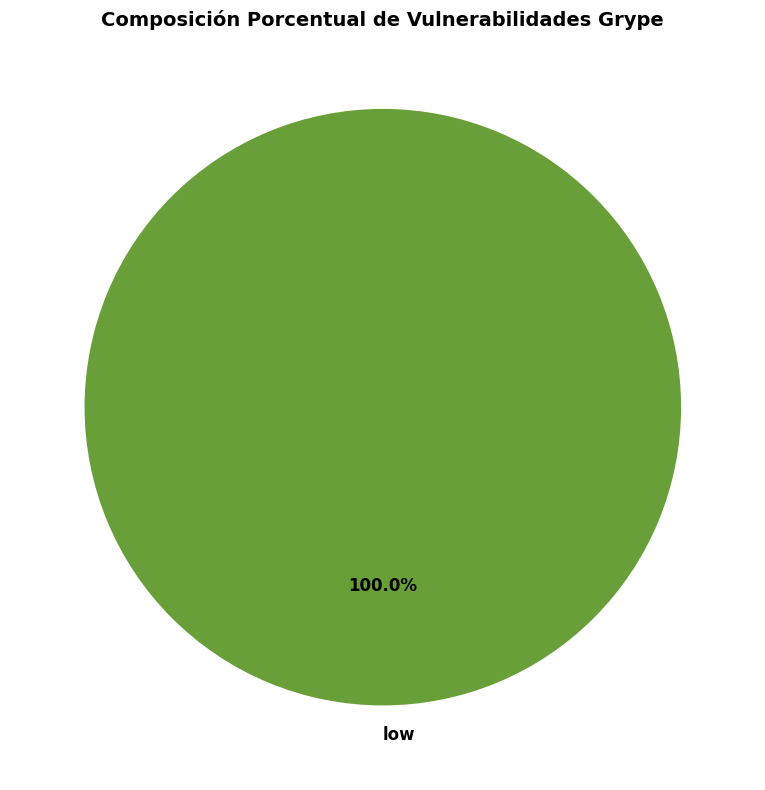

In [120]:
# Gráfico: Composición por severidad
if len(df_grype) > 0:
    fig, ax = plt.subplots(figsize=(10, 8))

    # Ordenar correctamente
    severidad_order = ['critical', 'high', 'medium', 'low']
    stats_severity = df_grype['vuln_severity'].value_counts()
    stats_severity = stats_severity.reindex(
        [s for s in severidad_order if s in stats_severity.index])

    colores = {'critical': '#b71c1c', 'high': '#e64a19',
               'medium': '#fbc02d', 'low': '#689f38'}
    color_list = [colores.get(nivel, '#757575')
                  for nivel in stats_severity.index]

    wedges, texts, autotexts = ax.pie(
        stats_severity.values,
        labels=stats_severity.index,
        autopct='%1.1f%%',
        colors=color_list,
        startangle=90,
        textprops={'fontsize': 12, 'weight': 'bold'}
    )

    ax.set_title('Composición Porcentual de Vulnerabilidades Grype',
                 fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print("❌ No hay datos disponibles para graficar")

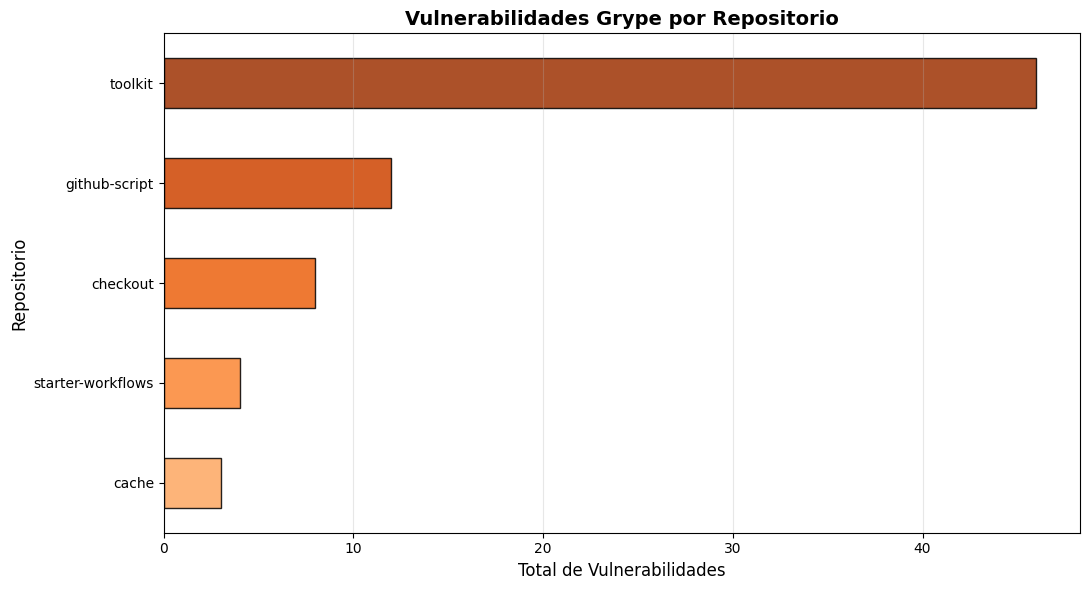


 Desviación estándar de vulnerabilidades por repositorio: 16.02
 Promedio de vulnerabilidades por repositorio: 14.60


In [121]:
# Gráfico: Vulnerabilidades por repositorio (Grype)
if len(df_grype) > 0:
    fig, ax = plt.subplots(figsize=(11, 6))

    vulns_por_repo = df_grype['repo'].value_counts(
    ).sort_values(ascending=True)

    # Colores del gradiente (más oscuro = más vulns)
    colores_gradiente = plt.cm.Oranges(
        np.linspace(0.4, 0.9, len(vulns_por_repo)))

    vulns_por_repo.plot(kind='barh', ax=ax,
                        color=colores_gradiente, edgecolor='black', alpha=0.85)

    ax.set_title('Vulnerabilidades Grype por Repositorio',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Total de Vulnerabilidades', fontsize=12)
    ax.set_ylabel('Repositorio', fontsize=12)
    ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("❌ No hay datos disponibles para graficar")

desv_p = 0
for cantidad_vulns in vulns_por_repo:
    desv_p += (cantidad_vulns - vulns_por_repo.mean()) ** 2
desv_p = (desv_p / len(vulns_por_repo)) ** 0.5
print(
    f"\n Desviación estándar de vulnerabilidades por repositorio: {desv_p:.2f}")
print(
    f" Promedio de vulnerabilidades por repositorio: {vulns_por_repo.mean():.2f}")

In [122]:
# Top 10 paquetes más vulnerables
if len(df_grype) > 0:
    # Agrupar por paquete y mostrar info relevante
    top_packages = df_grype['package_name'].value_counts().head(10)

    print("\n📦 Top 10 Paquetes con Más Vulnerabilidades:")
    print("=" * 80)
    print(f"{'Paquete':<30} {'Vulns':<10} {'Vers. Actual':<15} {'Fix?':<8}")
    print("=" * 80)

    for pkg_name in top_packages.index:
        pkg_data = df_grype[df_grype['package_name'] == pkg_name].iloc[0]
        cantidad = top_packages[pkg_name]
        version = pkg_data.get('current_version', 'N/A')
        fix = pkg_data.get('fix_version', 'N/A')
        fix_status = "✓ Sí" if fix != 'N/A' else "✗ No"

        print(f"{pkg_name:<30} {cantidad:<10} {str(version):<15} {fix_status:<8}")

else:
    print("❌ No hay datos disponibles")


📦 Top 10 Paquetes con Más Vulnerabilidades:
Paquete                        Vulns      Vers. Actual    Fix?    
undici                         26         5.29.0          ✗ No    
fast-xml-parser                15         5.5.6           ✗ No    
minimatch                      15         3.1.2           ✗ No    
brace-expansion                6          1.1.12          ✗ No    
uuid                           5          3.4.0           ✗ No    
js-yaml                        2          3.13.1          ✗ No    
lodash                         2          4.17.23         ✗ No    
sync-ghes-actions              1          1.0.0           ✗ No    
tar                            1          7.5.10          ✗ No    


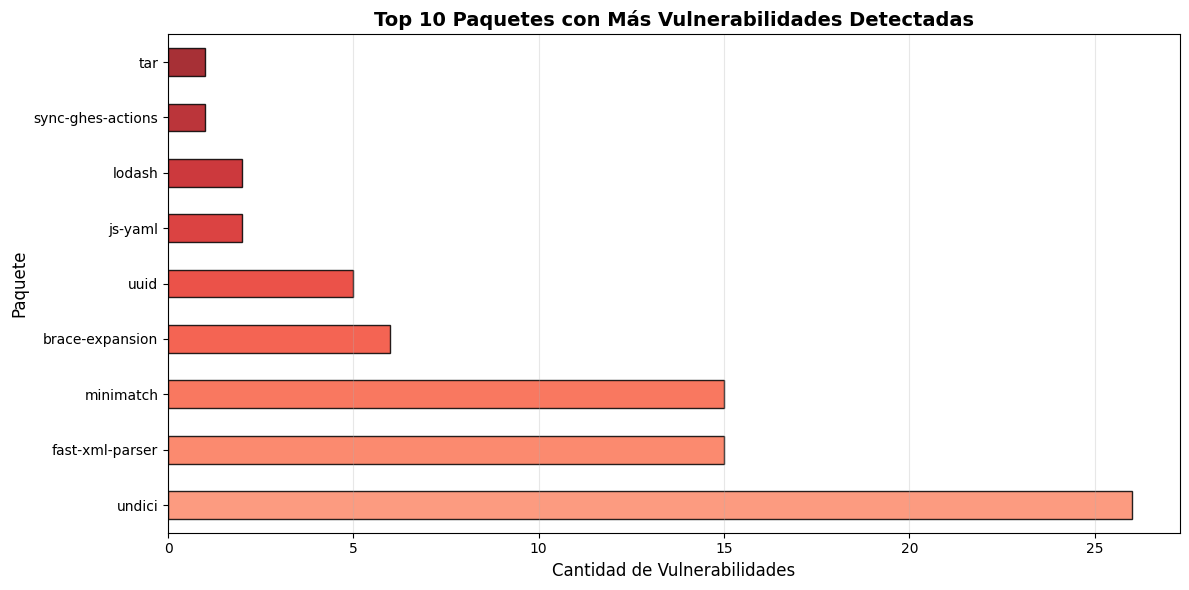

In [123]:
# Gráfico: Top 10 paquetes con más vulnerabilidades
if len(df_grype) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))

    top_packages = df_grype['package_name'].value_counts().head(10)

    # Colores del gradiente (más oscuro = más vulns)
    colores_gradiente = plt.cm.Reds(np.linspace(0.4, 0.9, len(top_packages)))

    top_packages.plot(kind='barh', ax=ax, color=colores_gradiente,
                      edgecolor='black', alpha=0.85)

    ax.set_title('Top 10 Paquetes con Más Vulnerabilidades Detectadas',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Cantidad de Vulnerabilidades', fontsize=12)
    ax.set_ylabel('Paquete', fontsize=12)
    ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("❌ No hay datos disponibles para graficar")

In [132]:
# | eval: false
# Mostrar vulnerabilidades detalladas
output_path_det = project_root / "data" / "results"
grype_files_det = sorted(output_path_det.glob("*-grype.json"))

if grype_files_det:
    for archivo_det in grype_files_det:
        with open(archivo_det, 'r', encoding='utf-8') as f:
            analisis_det = json.load(f)

        vulnerabilities_list = analisis_det.get('vulnerabilities', [])

        print(
            f"\n Total de vulnerabilidades en archivo {archivo_det.name}: {len(vulnerabilities_list)}")

        if vulnerabilities_list:
            # Crear DataFrame con las vulnerabilidades
            df_vulns = pd.DataFrame(vulnerabilities_list)

            # Seleccionar y reordenar columnas
            cols_mostrar = ['package_name', 'current_version',
                            'vuln_id', 'vuln_severity', 'fix_version', 'message']
            cols_disponibles = [
                c for c in cols_mostrar if c in df_vulns.columns]
            df_mostrar = df_vulns[cols_disponibles].head(20)
            print(f"{'='*120}")
            for idx, row in df_mostrar.iterrows():
                # Se añade mensaje para mayor información sobre la vulnerabilidad encontrada.
                print(
                    f"\n{idx+1}. [{row['vuln_severity'].upper()}] {row['vuln_id']} | Mensaje: {row['message']}")
                print(
                    f"{row['package_name']} (actual: {row['current_version']})")
                if pd.notna(row['fix_version']) and row['fix_version'] != 'N/A':
                    print(f"   ✓ Fix disponible en: {row['fix_version']}")

            if len(vulnerabilities_list) > 20:
                print(
                    f"\n... y {len(vulnerabilities_list)-20} vulnerabilidades más")
    else:
        print("No hay detalles de vulnerabilidades en el archivo")


 Total de vulnerabilidades en archivo cache-grype.json: 3

1. [LOW] GHSA-jp2q-39xq-3w4g | Mensaje: Entity Expansion Limits Bypassed When Set to Zero Due to JavaScript Falsy Evaluation in fast-xml-parser
fast-xml-parser (actual: 5.5.6)

2. [LOW] GHSA-f886-m6hf-6m8v | Mensaje: brace-expansion: Zero-step sequence causes process hang and memory exhaustion
brace-expansion (actual: 1.1.12)

3. [LOW] GHSA-gh4j-gqv2-49f6 | Mensaje: fast-xml-parser XMLBuilder: XML Comment and CDATA Injection via Unescaped Delimiters
fast-xml-parser (actual: 5.5.6)

 Total de vulnerabilidades en archivo checkout-grype.json: 8

1. [LOW] GHSA-v9p9-hfj2-hcw8 | Mensaje: Undici has Unhandled Exception in WebSocket Client Due to Invalid server_max_window_bits Validation
undici (actual: 5.29.0)

2. [LOW] GHSA-vrm6-8vpv-qv8q | Mensaje: Undici has Unbounded Memory Consumption in WebSocket permessage-deflate Decompression
undici (actual: 5.29.0)

3. [LOW] GHSA-g9mf-h72j-4rw9 | Mensaje: Undici has an unbounded decompressi

# Análisis de vulnerabilidades CodeQL: CI 

In [125]:
# Cargar todos los análisis CodeQL
codeql_files = sorted(data_results.glob("*-pipeline.json"))

print(f"\n📂 Buscando archivos CodeQL en: {data_results}")
print(f"✓ Archivos encontrados: {len(codeql_files)}\n")

# Consolidar en un solo DataFrame
data_consolidado = []

for archivo in codeql_files:
    with open(archivo, 'r', encoding='utf-8') as f:
        contenido = json.load(f)

    repo_name = archivo.stem.replace('-pipeline', '')
    issues = contenido.get('issues', [])

    for issue in issues:
        issue['repo'] = repo_name
        data_consolidado.append(issue)

df_codeql = pd.DataFrame(data_consolidado)

print(f"📊 Total de problemas cargados: {len(df_codeql)}")
print(
    f"📋 Repositorios únicos: {df_codeql['repo'].nunique() if len(df_codeql) > 0 else 0}\n")


📂 Buscando archivos CodeQL en: /workspaces/SBOMs-Tarea4/data/results
✓ Archivos encontrados: 5

📊 Total de problemas cargados: 34
📋 Repositorios únicos: 5



In [126]:
# Estadísticas por severidad
if len(df_codeql) > 0:
    stats_severity = df_codeql['level'].value_counts(
    ).sort_index(ascending=False)

    print("📊 Problemas por Nivel de Severidad:")
    print("=" * 50)
    for nivel, cantidad in stats_severity.items():
        emoji = "🔴" if nivel == "error" else "🟡" if nivel == "warning" else "⚪"
        porcentaje = (cantidad / len(df_codeql)) * 100
        print(f"{emoji} {nivel.upper()}: {cantidad} ({porcentaje:.1f}%)")

    print(f"\n📈 Total general: {len(df_codeql)} problemas encontrados")
else:
    print("❌ No hay datos de CodeQL disponibles")

📊 Problemas por Nivel de Severidad:
🟡 WARNING: 34 (100.0%)

📈 Total general: 34 problemas encontrados


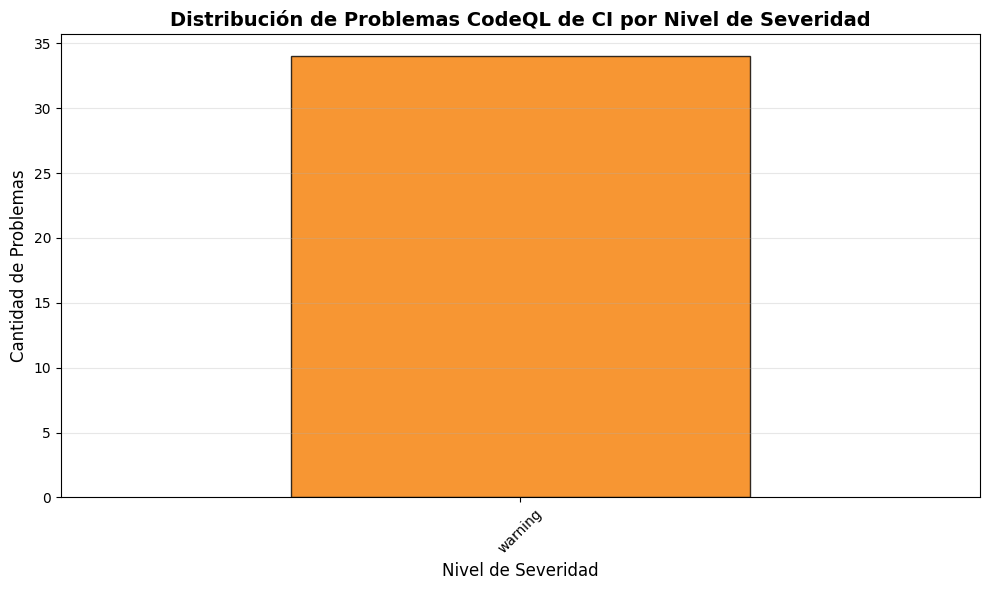

In [127]:
# Gráfico: Distribución por severidad
if len(df_codeql) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))

    stats_severity = df_codeql['level'].value_counts(
    ).sort_index(ascending=False)

    # Colores según severidad
    colores = {'error': '#d32f2f', 'warning': '#f57c00', 'note': '#7cb342'}
    color_list = [colores.get(nivel, '#757575')
                  for nivel in stats_severity.index]

    stats_severity.plot(kind='bar', ax=ax, color=color_list,
                        edgecolor='black', alpha=0.8)

    ax.set_title('Distribución de Problemas CodeQL de CI por Nivel de Severidad',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Nivel de Severidad', fontsize=12)
    ax.set_ylabel('Cantidad de Problemas', fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("❌ No hay datos disponibles para graficar")

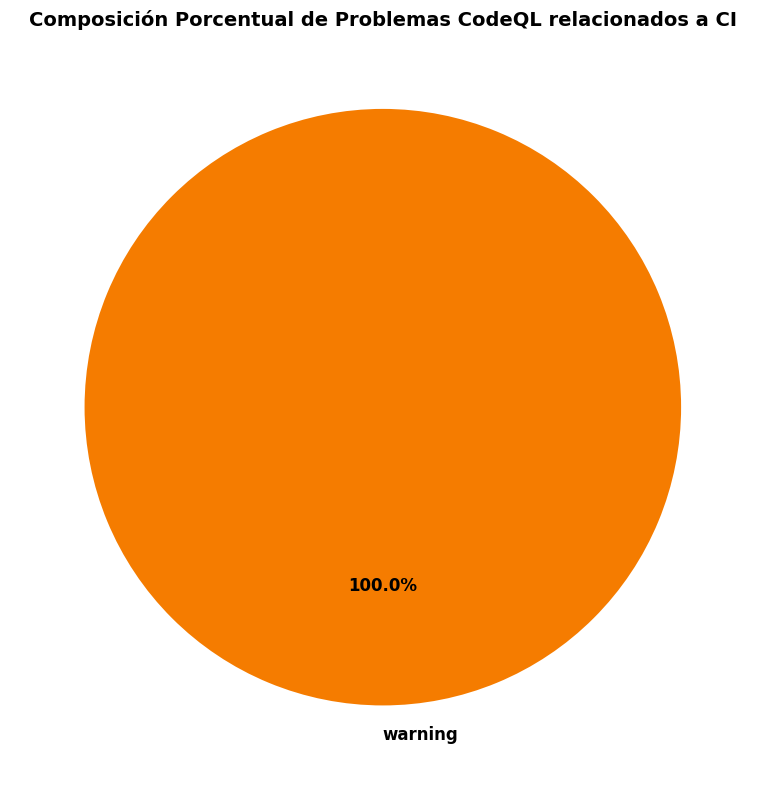

In [128]:
# Gráfico: Composición por severidad
if len(df_codeql) > 0:
    fig, ax = plt.subplots(figsize=(10, 8))

    stats_severity = df_codeql['level'].value_counts()

    colores = {'error': '#d32f2f', 'warning': '#f57c00', 'note': '#7cb342'}
    color_list = [colores.get(nivel, '#757575')
                  for nivel in stats_severity.index]

    wedges, texts, autotexts = ax.pie(
        stats_severity.values,
        labels=stats_severity.index,
        autopct='%1.1f%%',
        colors=color_list,
        startangle=90,
        textprops={'fontsize': 12, 'weight': 'bold'}
    )

    ax.set_title('Composición Porcentual de Problemas CodeQL relacionados a CI',
                 fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print("❌ No hay datos disponibles para graficar")

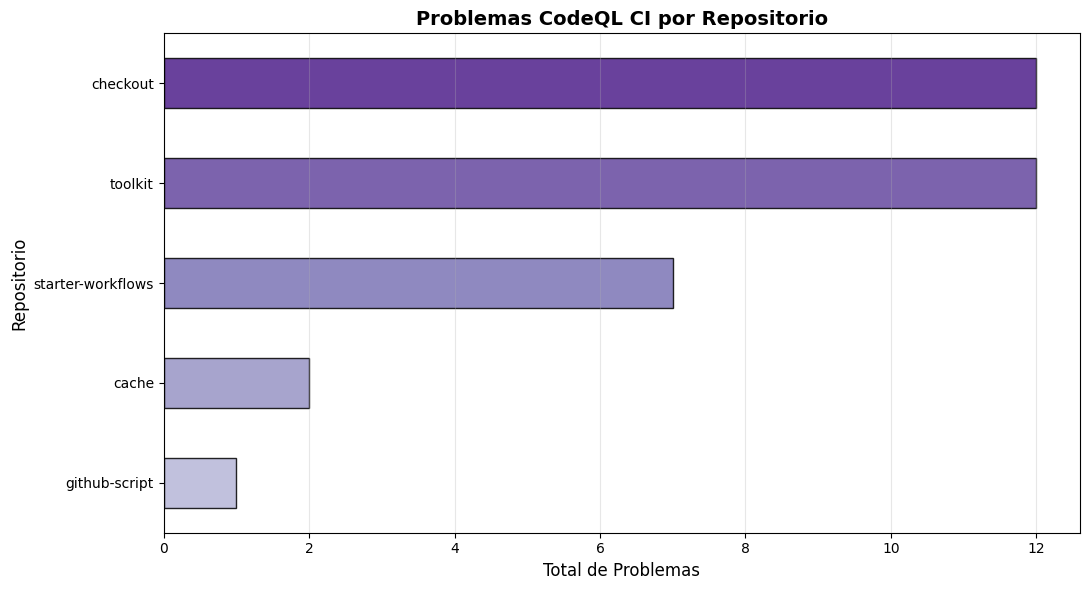

In [129]:
# Gráfico: Problemas por repositorio (CodeQL)
if len(df_codeql) > 0:
    fig, ax = plt.subplots(figsize=(11, 6))

    issues_por_repo = df_codeql['repo'].value_counts(
    ).sort_values(ascending=True)

    # Colores del gradiente (más oscuro = más issues)
    colores_gradiente = plt.cm.Purples(
        np.linspace(0.4, 0.9, len(issues_por_repo)))

    issues_por_repo.plot(
        kind='barh', ax=ax, color=colores_gradiente, edgecolor='black', alpha=0.85)

    ax.set_title('Problemas CodeQL CI por Repositorio',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Total de Problemas', fontsize=12)
    ax.set_ylabel('Repositorio', fontsize=12)
    ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("❌ No hay datos disponibles para graficar")

In [130]:
# Top 10 reglas más comunes
if len(df_codeql) > 0:
    top_rules = df_codeql['rule_id'].value_counts().head(10)

    print("\n🎯 Top 10 Reglas de Seguridad Más Frecuentes:")
    print("=" * 70)
    for idx, (rule, count) in enumerate(top_rules.items(), 1):
        porcentaje = (count / len(df_codeql)) * 100
        print(f"{idx:2d}. {rule:40s} {count:3d} ({porcentaje:5.1f}%)")
else:
    print("❌ No hay datos disponibles")


🎯 Top 10 Reglas de Seguridad Más Frecuentes:
 1. actions/missing-workflow-permissions      23 ( 67.6%)
 2. actions/unpinned-tag                       7 ( 20.6%)
 3. actions/unnecessary-use-of-advanced-config   4 ( 11.8%)


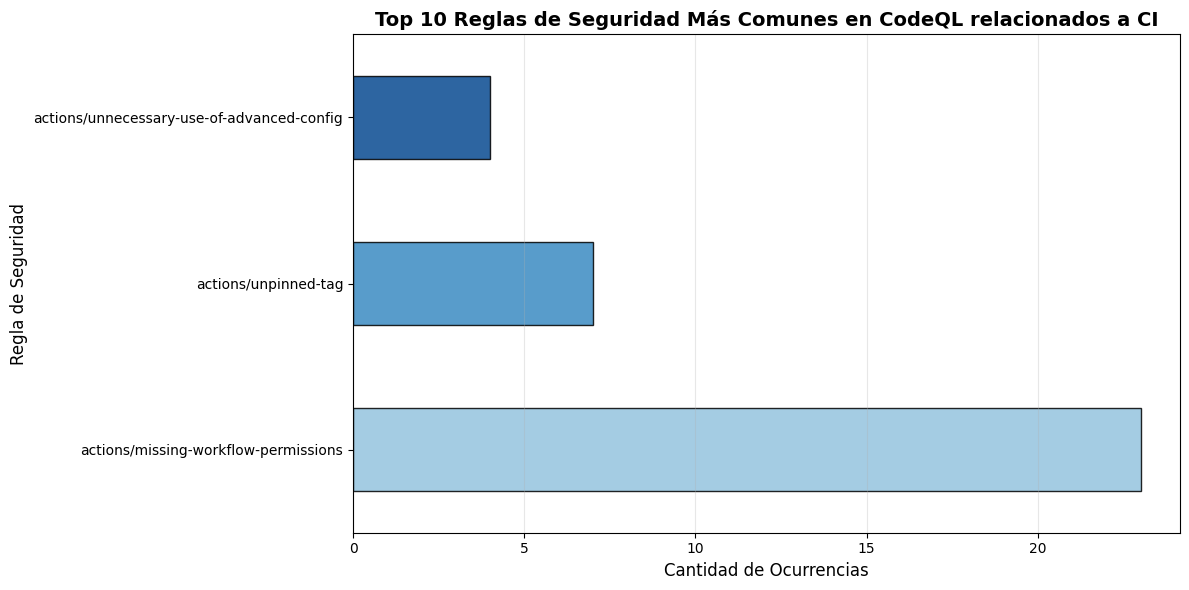

In [131]:
# Gráfico: Top 10 reglas más comunes
if len(df_codeql) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))

    top_rules = df_codeql['rule_id'].value_counts().head(10)

    # Colores del gradiente (más oscuro = más frecuente)
    colores_gradiente = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_rules)))

    top_rules.plot(kind='barh', ax=ax, color=colores_gradiente,
                   edgecolor='black', alpha=0.85)

    ax.set_title('Top 10 Reglas de Seguridad Más Comunes en CodeQL relacionados a CI',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Cantidad de Ocurrencias', fontsize=12)
    ax.set_ylabel('Regla de Seguridad', fontsize=12)
    ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("❌ No hay datos disponibles para graficar")